In [2]:
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw

ROOT = Path.cwd()
YOLO_DIR = ROOT / 'data' / 'drone_dataset_yolo' / 'dataset_txt'
XML_DIR = ROOT / 'data' / 'dataset_xml_format' / 'dataset_xml_format'
CLASSES_PATH = YOLO_DIR / 'classes.txt'

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def index_dataset(folder: Path, label_suffix: str):
    image_files = {path.stem: path for path in folder.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS}
    label_files = {path.stem: path for path in folder.iterdir() if path.suffix.lower() == label_suffix}
    common_stems = sorted(image_files.keys() & label_files.keys())
    return {
        'images': image_files,
        'labels': label_files,
        'common_stems': common_stems,
        'image_only': sorted(image_files.keys() - label_files.keys()),
        'label_only': sorted(label_files.keys() - image_files.keys()),
    }

classes = []
if CLASSES_PATH.exists():
    classes = [line.strip() for line in CLASSES_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]

yolo_index = index_dataset(YOLO_DIR, '.txt')
xml_index = index_dataset(XML_DIR, '.xml')

summary = pd.DataFrame(
    [
        {
            'dataset': 'YOLO txt',
            'images': len(yolo_index['images']),
            'labels': len(yolo_index['labels']),
            'paired_samples': len(yolo_index['common_stems']),
            'images_without_labels': len(yolo_index['image_only']),
            'labels_without_images': len(yolo_index['label_only']),
        },
        {
            'dataset': 'XML',
            'images': len(xml_index['images']),
            'labels': len(xml_index['labels']),
            'paired_samples': len(xml_index['common_stems']),
            'images_without_labels': len(xml_index['image_only']),
            'labels_without_images': len(xml_index['label_only']),
        },
    ]
 )

summary

,dataset,images,labels,paired_samples,images_without_labels,labels_without_images
0,YOLO txt,1359,1360,1359,0,1
1,XML,1097,1097,1097,0,0


## Dataset Comparison
This section compares the YOLO `.txt` annotations with the Pascal VOC `.xml` annotations by sample name, object count, class label, and bounding box coordinates.

In [3]:
def parse_xml_boxes(xml_path: Path):
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall('object'):
        name = obj.findtext('name', default='unknown').strip()
        box = obj.find('bndbox')
        if box is None:
            continue
        xmin = float(box.findtext('xmin', default='0'))
        ymin = float(box.findtext('ymin', default='0'))
        xmax = float(box.findtext('xmax', default='0'))
        ymax = float(box.findtext('ymax', default='0'))
        boxes.append({
            'label': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax,
        })
    return boxes

def parse_yolo_boxes(txt_path: Path, image_path: Path):
    width, height = Image.open(image_path).size
    boxes = []
    raw_text = txt_path.read_text(encoding='utf-8').strip()
    if not raw_text:
        return boxes
    for line in raw_text.splitlines():
        class_id, center_x, center_y, box_width, box_height = line.split()[:5]
        class_index = int(float(class_id))
        label = classes[class_index] if 0 <= class_index < len(classes) else f'class_{class_index}'
        center_x = float(center_x) * width
        center_y = float(center_y) * height
        box_width = float(box_width) * width
        box_height = float(box_height) * height
        boxes.append({
            'label': label,
            'xmin': center_x - box_width / 2,
            'ymin': center_y - box_height / 2,
            'xmax': center_x + box_width / 2,
            'ymax': center_y + box_height / 2,
        })
    return boxes

def normalize_boxes(boxes, decimals=1):
    normalized = []
    for box in boxes:
        normalized.append(
            (
                box['label'],
                round(box['xmin'], decimals),
                round(box['ymin'], decimals),
                round(box['xmax'], decimals),
                round(box['ymax'], decimals),
            )
        )
    return sorted(normalized)

def compare_boxes(xml_boxes, yolo_boxes, tolerance=2.0):
    if len(xml_boxes) != len(yolo_boxes):
        return False, f'Object count differs: xml={len(xml_boxes)}, yolo={len(yolo_boxes)}'

    xml_sorted = sorted(xml_boxes, key=lambda item: (item['label'], item['xmin'], item['ymin'], item['xmax'], item['ymax']))
    yolo_sorted = sorted(yolo_boxes, key=lambda item: (item['label'], item['xmin'], item['ymin'], item['xmax'], item['ymax']))

    for xml_box, yolo_box in zip(xml_sorted, yolo_sorted):
        if xml_box['label'] != yolo_box['label']:
            return False, f"Class differs: xml={xml_box['label']}, yolo={yolo_box['label']}"
        deltas = [
            abs(xml_box['xmin'] - yolo_box['xmin']),
            abs(xml_box['ymin'] - yolo_box['ymin']),
            abs(xml_box['xmax'] - yolo_box['xmax']),
            abs(xml_box['ymax'] - yolo_box['ymax']),
        ]
        if max(deltas) > tolerance:
            return False, f'Box coordinates differ by more than {tolerance} pixels'
    return True, 'match'

shared_stems = sorted(set(xml_index['common_stems']) & set(yolo_index['common_stems']))
only_in_yolo = sorted(set(yolo_index['common_stems']) - set(xml_index['common_stems']))
only_in_xml = sorted(set(xml_index['common_stems']) - set(yolo_index['common_stems']))

comparison_rows = []
mismatch_details = []

for stem in shared_stems:
    xml_boxes = parse_xml_boxes(xml_index['labels'][stem])
    yolo_boxes = parse_yolo_boxes(yolo_index['labels'][stem], yolo_index['images'][stem])
    same, reason = compare_boxes(xml_boxes, yolo_boxes)
    comparison_rows.append({
        'stem': stem,
        'xml_objects': len(xml_boxes),
        'yolo_objects': len(yolo_boxes),
        'same_annotation': same,
        'reason': reason,
        'xml_labels': ', '.join(sorted({box['label'] for box in xml_boxes})) or 'none',
        'yolo_labels': ', '.join(sorted({box['label'] for box in yolo_boxes})) or 'none',
    })
    if not same:
        mismatch_details.append({
            'stem': stem,
            'reason': reason,
            'xml_boxes': normalize_boxes(xml_boxes),
            'yolo_boxes': normalize_boxes(yolo_boxes),
        })

comparison_df = pd.DataFrame(comparison_rows)

overview = pd.Series({
    'shared_samples_between_formats': len(shared_stems),
    'samples_only_in_yolo': len(only_in_yolo),
    'samples_only_in_xml': len(only_in_xml),
    'matching_annotations': int(comparison_df['same_annotation'].sum()),
    'mismatching_annotations': int((~comparison_df['same_annotation']).sum()),
    'all_shared_annotations_match': bool(comparison_df['same_annotation'].all()),
})

display(pd.DataFrame({'classes_from_yolo': classes or ['<missing classes.txt>']}))
display(overview.to_frame(name='value'))
display(comparison_df.head(10))

if mismatch_details:
    display(pd.DataFrame(mismatch_details[:10]))
else:
    print('All shared YOLO and XML annotations match within the tolerance threshold.')

print('Examples only in YOLO:', only_in_yolo[:10])
print('Examples only in XML:', only_in_xml[:10])

,classes_from_yolo
0,drone


,value
shared_samples_between_formats,996
samples_only_in_yolo,363
samples_only_in_xml,101
matching_annotations,994
mismatching_annotations,2
all_shared_annotations_match,False


,stem,xml_objects,yolo_objects,same_annotation,reason,xml_labels,yolo_labels
0,foto00088,1,1,True,match,drone,drone
1,foto00117,1,1,True,match,drone,drone
2,foto00204,1,1,True,match,drone,drone
3,foto00233,1,1,True,match,drone,drone
4,foto00262,1,1,True,match,drone,drone
5,foto00291,1,1,True,match,drone,drone
6,foto00320,1,1,True,match,drone,drone
7,foto00349,1,1,True,match,drone,drone
8,foto00378,1,1,True,match,drone,drone
9,foto00987,1,1,True,match,drone,drone


,stem,reason,xml_boxes,yolo_boxes
0,pic_009,Box coordinates differ by more than 2.0 pixels,"[(drone, 315.0, 840.0, 4119.0, 2479.0), (drone...","[(drone, 315.0, 841.9, 4117.5, 2480.6), (drone..."
1,pic_092,Box coordinates differ by more than 2.0 pixels,"[(drone, 943.0, 471.0, 4080.0, 2775.0)]","[(drone, 945.0, 471.2, 4080.8, 2774.2)]"


Examples only in YOLO: ['0001', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011']
Examples only in XML: ['moto00030', 'moto00059', 'moto00088', 'moto00900', 'moto00929', 'moto00958', 'moto01799', 'moto01828', 'moto01857', 'moto01886']


## Visual Check
These plots overlay XML boxes and YOLO boxes on a few shared samples so you can inspect whether both annotations line up visually.

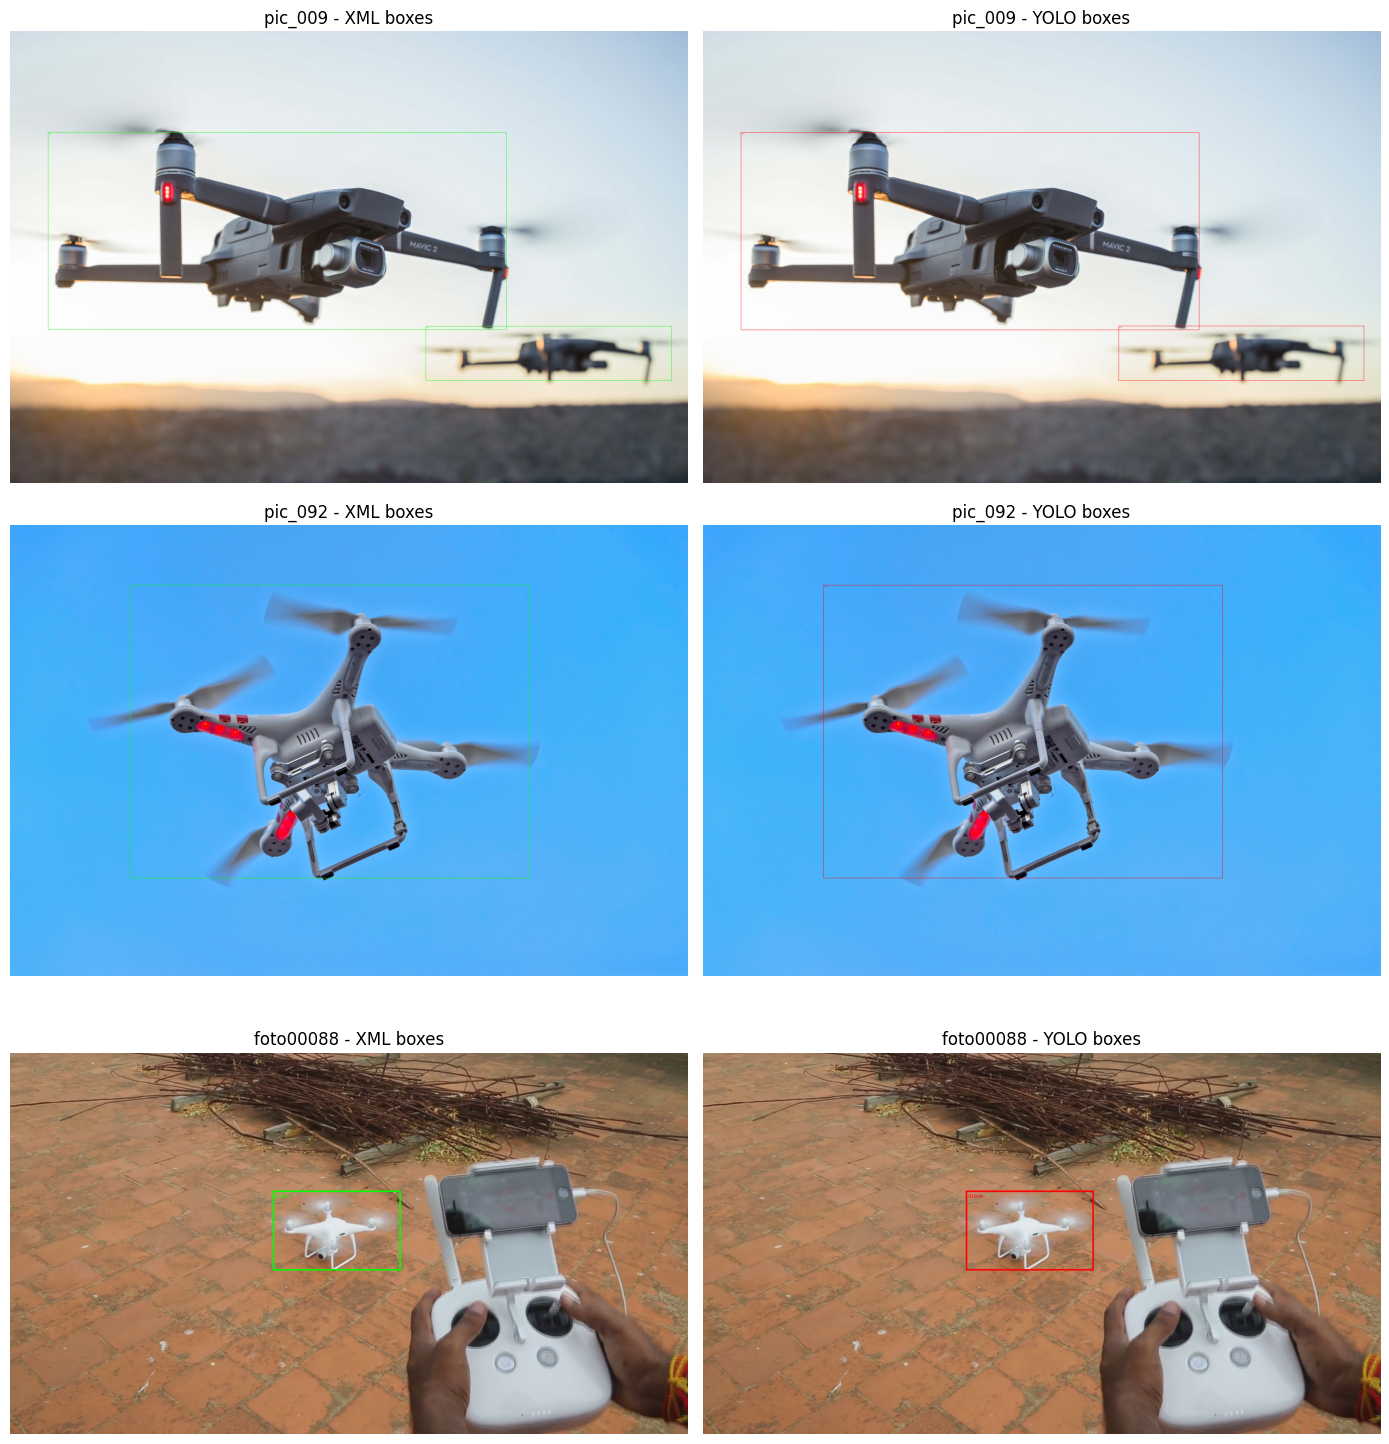

In [4]:
def draw_boxes(image_path: Path, boxes, color):
    image = Image.open(image_path).convert('RGB')
    canvas = image.copy()
    drawer = ImageDraw.Draw(canvas)
    for box in boxes:
        drawer.rectangle(
            [(box['xmin'], box['ymin']), (box['xmax'], box['ymax'])],
            outline=color,
            width=3,
        )
        drawer.text((box['xmin'] + 4, box['ymin'] + 4), box['label'], fill=color)
    return canvas

samples_to_plot = [item['stem'] for item in mismatch_details[:3]]
if len(samples_to_plot) < 3:
    matched_examples = [stem for stem in shared_stems if stem not in samples_to_plot][: 3 - len(samples_to_plot)]
    samples_to_plot.extend(matched_examples)

if not samples_to_plot:
    raise ValueError('No shared samples were found to visualize.')

fig, axes = plt.subplots(len(samples_to_plot), 2, figsize=(14, 5 * len(samples_to_plot)))
if len(samples_to_plot) == 1:
    axes = [axes]

for row_index, stem in enumerate(samples_to_plot):
    xml_boxes = parse_xml_boxes(xml_index['labels'][stem])
    yolo_boxes = parse_yolo_boxes(yolo_index['labels'][stem], yolo_index['images'][stem])
    base_image_path = xml_index['images'].get(stem, yolo_index['images'][stem])

    xml_image = draw_boxes(base_image_path, xml_boxes, color='lime')
    yolo_image = draw_boxes(base_image_path, yolo_boxes, color='red')

    axes[row_index][0].imshow(xml_image)
    axes[row_index][0].set_title(f'{stem} - XML boxes')
    axes[row_index][1].imshow(yolo_image)
    axes[row_index][1].set_title(f'{stem} - YOLO boxes')

    for axis in axes[row_index]:
        axis.axis('off')

plt.tight_layout()
plt.show()

## Build Unified Train/Validation/Test Dataset
This section creates one merged dataset with a single label format. YOLO `.txt` is used for all samples because it is the better fit for most modern object detection training pipelines, and XML-only samples are converted to YOLO format.

In [ ]:
import random
import shutil

MERGED_DIR = ROOT / 'data' / 'merged_drone_dataset_yolo'
SPLIT_RATIOS = {'train': 0.7, 'val': 0.15, 'test': 0.15}
RANDOM_SEED = 42

def choose_image_path(stem: str):
    return yolo_index['images'].get(stem) or xml_index['images'].get(stem)

def collect_class_names():
    names = list(classes)
    for stem in xml_index['common_stems'] + only_in_xml:
        for box in parse_xml_boxes(xml_index['labels'][stem]):
            if box['label'] not in names:
                names.append(box['label'])
    return names

ALL_CLASSES = collect_class_names()
CLASS_TO_ID = {label: index for index, label in enumerate(ALL_CLASSES)}

def build_combined_records():
    candidate_stems = sorted(set(yolo_index['common_stems']) | set(xml_index['common_stems']))
    records = []
    for stem in candidate_stems:
        image_path = choose_image_path(stem)
        txt_path = yolo_index['labels'].get(stem)
        xml_path = xml_index['labels'].get(stem)
        if image_path is None:
            continue
        records.append({
            'stem': stem,
            'image_path': image_path,
            'txt_path': txt_path,
            'xml_path': xml_path,
            'source_format': 'txt' if txt_path is not None else 'xml',
        })
    return records

def assign_splits(records, ratios, seed):
    shuffled = records.copy()
    random.Random(seed).shuffle(shuffled)
    total = len(shuffled)
    train_end = int(total * ratios['train'])
    val_end = train_end + int(total * ratios['val'])

    split_map = {}
    for index, record in enumerate(shuffled):
        if index < train_end:
            split = 'train'
        elif index < val_end:
            split = 'val'
        else:
            split = 'test'
        split_map[record['stem']] = split
    return split_map

def reset_split_dirs(root_dir: Path):
    if root_dir.exists():
        shutil.rmtree(root_dir)
    for split in ('train', 'val', 'test'):
        for subfolder in ('images', 'labels'):
            (root_dir / split / subfolder).mkdir(parents=True, exist_ok=True)

def xml_boxes_to_yolo_lines(xml_path: Path, image_path: Path):
    width, height = Image.open(image_path).size
    yolo_lines = []
    for box in parse_xml_boxes(xml_path):
        class_id = CLASS_TO_ID[box['label']]
        center_x = ((box['xmin'] + box['xmax']) / 2) / width
        center_y = ((box['ymin'] + box['ymax']) / 2) / height
        box_width = (box['xmax'] - box['xmin']) / width
        box_height = (box['ymax'] - box['ymin']) / height
        yolo_lines.append(f'{class_id} {center_x:.6f} {center_y:.6f} {box_width:.6f} {box_height:.6f}')
    return yolo_lines

combined_records = build_combined_records()
split_by_stem = assign_splits(combined_records, SPLIT_RATIOS, RANDOM_SEED)
reset_split_dirs(MERGED_DIR)

for record in combined_records:
    split = split_by_stem[record['stem']]
    image_target = MERGED_DIR / split / 'images' / f"{record['stem']}{record['image_path'].suffix.lower()}"
    label_target = MERGED_DIR / split / 'labels' / f"{record['stem']}.txt"
    shutil.copy2(record['image_path'], image_target)

    if record['txt_path'] is not None:
        shutil.copy2(record['txt_path'], label_target)
    elif record['xml_path'] is not None:
        label_target.write_text('\n'.join(xml_boxes_to_yolo_lines(record['xml_path'], record['image_path'])), encoding='utf-8')

(MERGED_DIR / 'classes.txt').write_text('\n'.join(ALL_CLASSES) + '\n', encoding='utf-8')
(MERGED_DIR / 'dataset.yaml').write_text(
    '\n'.join([
        f'path: {MERGED_DIR.as_posix()}',
        'train: train/images',
        'val: val/images',
        'test: test/images',
        'names:',
        *[f'  {index}: {label}' for index, label in enumerate(ALL_CLASSES)],
    ]) + '\n',
    encoding='utf-8',
)

manifest_df = pd.DataFrame(combined_records)
manifest_df['split'] = manifest_df['stem'].map(split_by_stem)
manifest_df['image_name'] = manifest_df['image_path'].map(lambda path: path.name)
manifest_df['label_name'] = manifest_df['stem'] + '.txt'
manifest_df = manifest_df[['stem', 'split', 'source_format', 'image_name', 'label_name']]
manifest_df.to_csv(MERGED_DIR / 'manifest.csv', index=False)

split_summary = (
    manifest_df.groupby(['split', 'source_format'])
    .size()
    .unstack(fill_value=0)
    .reindex(['train', 'val', 'test'])
    .fillna(0)
    .astype(int)
    .reset_index()
 )

display(pd.DataFrame({'class_name': ALL_CLASSES, 'class_id': range(len(ALL_CLASSES))}))
display(split_summary)
display(manifest_df.head(10))
print(f'Unified YOLO dataset created at: {MERGED_DIR}')
print(f'Total merged samples: {len(manifest_df)}')

,class_name,class_id
0,drone,0


source_format,split,txt,xml
0,train,947,74
1,val,204,15
2,test,208,12


,stem,split,source_format,image_name,label_name
0,0001,train,txt,0001.jpg,0001.txt
1,0003,test,txt,0003.jpg,0003.txt
2,0004,train,txt,0004.jpg,0004.txt
3,0005,train,txt,0005.jpg,0005.txt
4,0006,val,txt,0006.jpg,0006.txt
5,0007,train,txt,0007.jpg,0007.txt
6,0008,test,txt,0008.jpg,0008.txt
7,0009,val,txt,0009.jpg,0009.txt
8,0010,train,txt,0010.jpg,0010.txt
9,0011,train,txt,0011.jpg,0011.txt


Unified YOLO dataset created at: d:\college\semester6\deep_learning\drone_detection\data\merged_drone_dataset_yolo
Total merged samples: 1460


: 